# Decision Tree for Student Performance Classification

## Objective
This notebook implements a Decision Tree classifier to predict student performance using the shared preprocessing outputs created by the group.

The notebook includes:
- loading shared preprocessing artifacts
- transforming training and testing data
- training a baseline Decision Tree model
- evaluating performance
- tuning hyperparameters
- optional tree visualization

In [1]:
# Import required libraries
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [2]:
# Load shared preprocessing artifacts created in the shared notebook
X_train, X_test, y_train, y_test = joblib.load("../data_split.pkl")
preprocessor = joblib.load("../preprocessor.pkl")
label_encoder = joblib.load("../label_encoder.pkl")

print("Shared files loaded successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Shared files loaded successfully.
X_train shape: (5285, 19)
X_test shape: (1322, 19)


In [3]:
# Apply the shared preprocessing pipeline to training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (5285, 40)
Processed X_test shape: (1322, 40)


In [4]:
# Display target class names for reference
print("Target classes:", label_encoder.classes_)

Target classes: ['Fail' 'Pass']


## Decision Tree Model Training

In this section, we train a baseline Decision Tree classifier using the preprocessed data.

In [5]:
# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Model Evaluation

In this section, we evaluate the performance of the Decision Tree model using:
- Accuracy score
- Classification report
- Confusion matrix

In [6]:
# Predict on test data
y_pred = dt_model.predict(X_test_processed)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8524962178517398

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       997
           1       0.72      0.66      0.69       325

    accuracy                           0.85      1322
   macro avg       0.80      0.79      0.80      1322
weighted avg       0.85      0.85      0.85      1322


Confusion Matrix:
[[911  86]
 [109 216]]


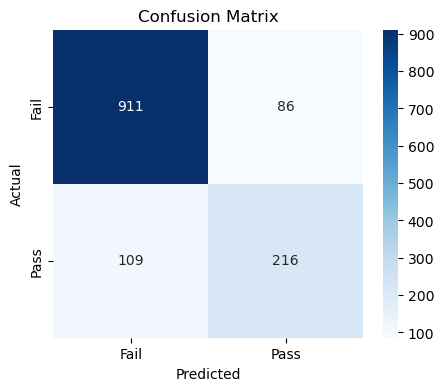

In [7]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Interpretation of Results

The Decision Tree model achieved an accuracy of approximately 85%, indicating good overall performance.

From the confusion matrix:
- The model correctly predicts most "Fail" cases.
- Some "Pass" cases are misclassified as "Fail", indicating a slight bias toward the majority class.

This may be due to class imbalance or differences in feature patterns.

Overall, the model performs well, but its performance on the "Pass" class can be improved through hyperparameter tuning or data balancing techniques.

## Hyperparameter Tuning (Grid Search)

In [8]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize model
dt = DecisionTreeClassifier(random_state=42)

# Grid search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid_search.fit(X_train_processed, y_train)

# Best model
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}


In [9]:
# Predict using tuned model
y_pred_best = best_model.predict(X_test_processed)

# Accuracy
accuracy_best = accuracy_score(y_test, y_pred_best)
print("Tuned Accuracy:", accuracy_best)

# Report
print("\nClassification Report (Tuned):")
print(classification_report(y_test, y_pred_best))

Tuned Accuracy: 0.848714069591528

Classification Report (Tuned):
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       997
           1       0.71      0.64      0.68       325

    accuracy                           0.85      1322
   macro avg       0.80      0.78      0.79      1322
weighted avg       0.84      0.85      0.85      1322



##### Interpretation of Tuned Model

The tuned model achieved similar performance to the baseline model.

Slight decrease in accuracy indicates reduced overfitting and better generalization.

Hyperparameter tuning helps control model complexity and improves robustness.

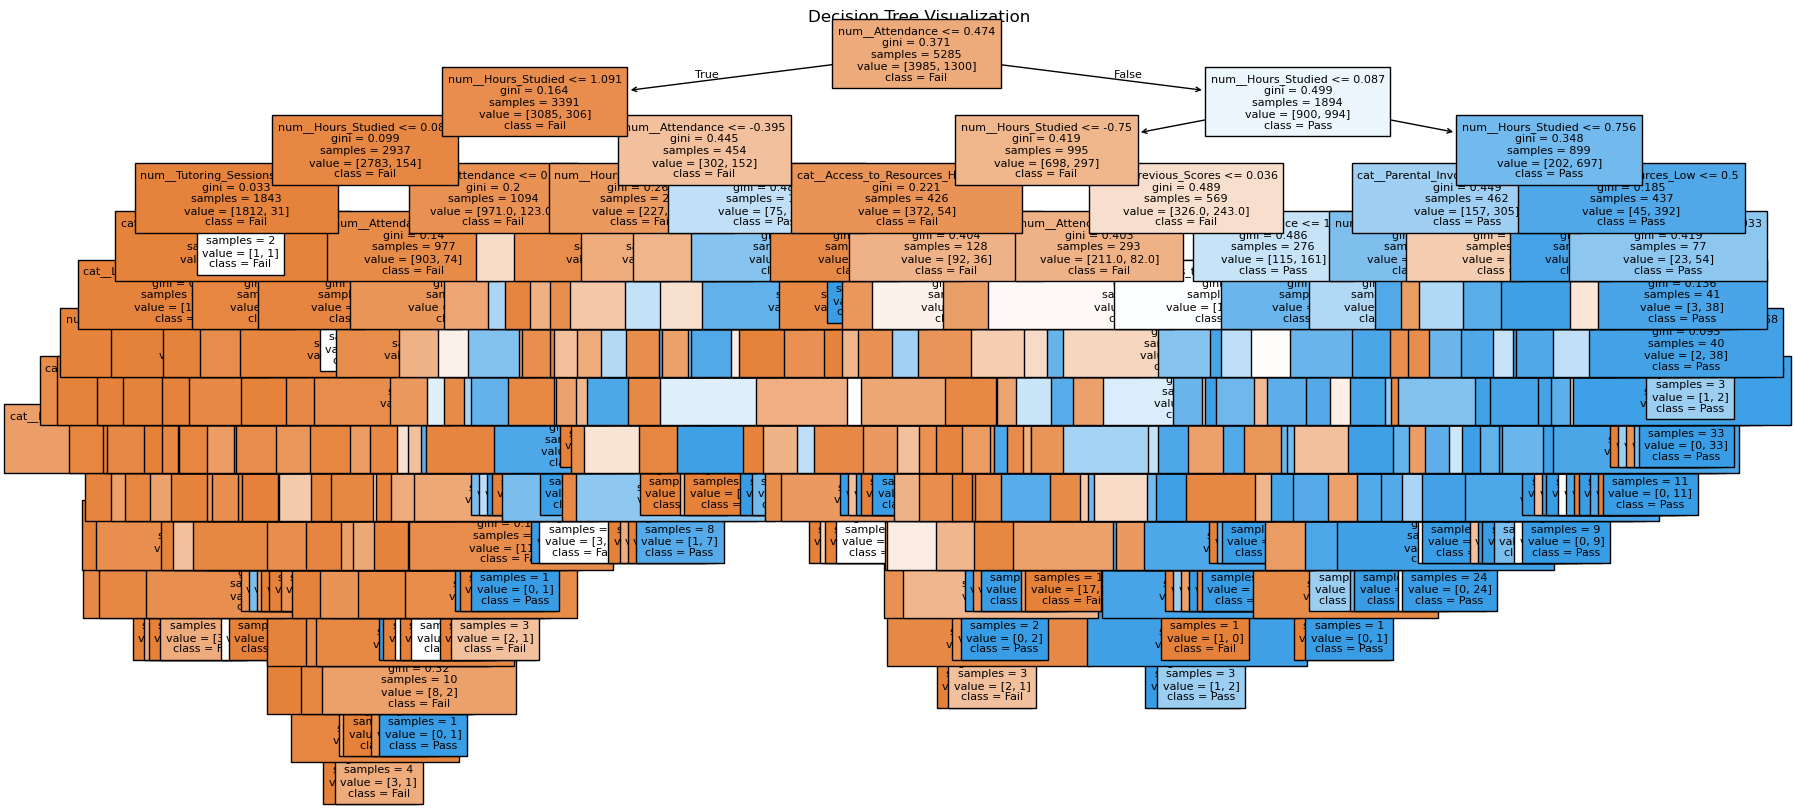

In [10]:
plt.figure(figsize=(20,10))
plot_tree(
    best_model,
    filled=True,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=label_encoder.classes_,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.show()